In [1]:
import kagglehub

path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Dataset downloaded to: /kaggle/input/california-housing-prices
['housing.csv']


In [2]:
# Load the dataset and take a first look
import pandas as pd

df = pd.read_csv(f"{path}/housing.csv")

print("Shape:", df.shape)
print("\nColumn info:")
df.info()
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 10)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Missing values, stats, and target distribution
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nocean_proximity categories:\n", df['ocean_proximity'].value_counts())
df.describe()

Missing values:
 total_bedrooms    207
dtype: int64

ocean_proximity categories:
 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


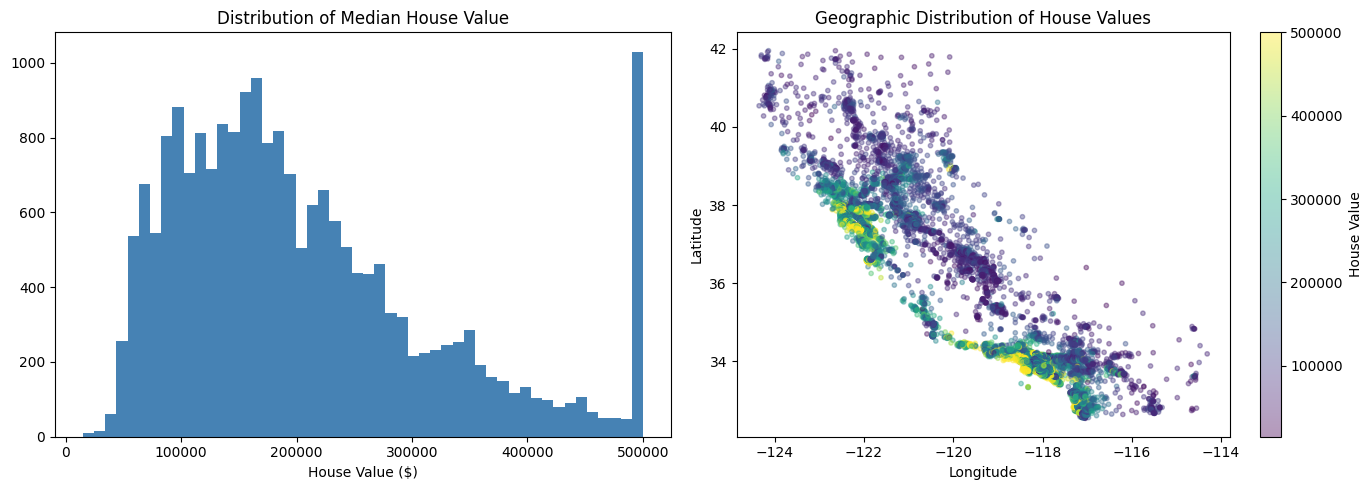

In [4]:
# Cell 4: Visualize target distribution and geographic spread
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('House Value ($)')

scatter = axes[1].scatter(df['longitude'], df['latitude'],
                           c=df['median_house_value'], cmap='viridis',
                           alpha=0.4, s=10)
axes[1].set_title('Geographic Distribution of House Values')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[1], label='House Value')
plt.tight_layout()
plt.show()

In [5]:
# Cell 5: Remove capped house values (data artifact, not real prices)
print("Rows at exactly $500,000+:", (df['median_house_value'] >= 500000).sum())

df = df[df['median_house_value'] < 500000].copy()
print("New shape after removing capped values:", df.shape)

Rows at exactly $500,000+: 992
New shape after removing capped values: (19648, 10)


In [6]:
# Cell 7: Engineer geospatial features — distance to major CA cities + KMeans location clusters
import numpy as np
from sklearn.cluster import KMeans

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Major California economic hubs — proximity to these strongly drives price
major_cities = {
    'san_francisco': (37.7749, -122.4194),
    'los_angeles': (34.0522, -118.2437),
    'san_diego': (32.7157, -117.1611),
    'san_jose': (37.3382, -121.8863),
}

for city, (city_lat, city_lon) in major_cities.items():
    df[f'dist_to_{city}'] = haversine_distance(df['latitude'], df['longitude'], city_lat, city_lon)

df['dist_to_nearest_city'] = df[[f'dist_to_{c}' for c in major_cities]].min(axis=1)

# KMeans geographic clustering — lets the model learn region-specific pricing patterns
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

print(df[['dist_to_nearest_city', 'geo_cluster']].describe())
print("\nCluster counts:\n", df['geo_cluster'].value_counts().sort_index())

       dist_to_nearest_city   geo_cluster
count          19648.000000  19648.000000
mean              71.380752      5.419025
std               77.148659      3.787755
min                0.383481      0.000000
25%               17.308957      2.000000
50%               37.908885      5.000000
75%               96.985076      9.000000
max              489.115960     14.000000

Cluster counts:
 geo_cluster
0     3010
1      977
2     1562
3      905
4     2791
5     1308
6      386
7     1325
8     1233
9     4308
10     421
11     448
12     267
13     514
14     193
Name: count, dtype: int64


In [7]:
# Cell 8: Engineer ratio-based features (classic per Aurélien Géron's approach, but essential)
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['income_per_room'] = df['median_income'] / df['rooms_per_household']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_room']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household,income_per_room
count,19648.000000,19448.000000,19648.000000,19648.000000
mean,5.361708,0.214933,3.096560,0.694101
std,2.293321,0.056922,10.639195,0.231594
min,0.846154,0.100000,0.692308,0.022608
25%,4.416667,0.177648,2.446614,0.533903
50%,5.185730,0.204545,2.837779,0.695478
75%,5.971083,0.240879,3.306021,0.842561
max,132.533333,1.000000,1243.333333,5.168025


In [8]:
# Cell 9: Diagnose and fix division-by-zero artifacts and extreme outliers
print("Rows with total_rooms == 0:", (df['total_rooms'] == 0).sum())
print("Rows with households == 0:", (df['households'] == 0).sum())
print("Infinite values in engineered features:")
for col in ['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_room']:
    print(f"  {col}: {np.isinf(df[col]).sum()} inf, {df[col].isnull().sum()} NaN")

# Drop rows where households or total_rooms is 0 — these are degenerate/invalid records
df = df[(df['households'] > 0) & (df['total_rooms'] > 0)].copy()

# Recompute the ratios cleanly now that the bad rows are gone
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['income_per_room'] = df['median_income'] / df['rooms_per_household']

print("\nNew shape:", df.shape)
print("Remaining NaN/inf check:", df[['rooms_per_household','bedrooms_per_room','population_per_household','income_per_room']].isnull().sum().sum())

Rows with total_rooms == 0: 0
Rows with households == 0: 0
Infinite values in engineered features:
  rooms_per_household: 0 inf, 0 NaN
  bedrooms_per_room: 0 inf, 200 NaN
  population_per_household: 0 inf, 0 NaN
  income_per_room: 0 inf, 0 NaN

New shape: (19648, 20)
Remaining NaN/inf check: 200


In [9]:
# Cell 10: Cap extreme outliers in population_per_household using IQR
Q1 = df['population_per_household'].quantile(0.25)
Q3 = df['population_per_household'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # using 3x IQR (conservative) rather than the usual 1.5x, since this is a legitimate but skewed feature

print(f"Upper bound: {upper_bound:.2f}, values above it: {(df['population_per_household'] > upper_bound).sum()}")
df['population_per_household'] = df['population_per_household'].clip(upper=upper_bound)

df['population_per_household'].describe()

Upper bound: 5.88, values above it: 124


,population_per_household
count,19648.000000
mean,2.940240
std,0.748579
min,0.692308
25%,2.446614
50%,2.837779
75%,3.306021
max,5.884240


In [10]:
# Cell 11: Run iterative imputation now (this was missed earlier) and rebuild ratios
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                'total_bedrooms', 'population', 'households', 'median_income']

print("Missing before imputation:", df['total_bedrooms'].isnull().sum())

imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
    random_state=42,
    max_iter=10
)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Missing after imputation:", df['total_bedrooms'].isnull().sum())

# Now rebuild the ratio features cleanly, since total_bedrooms just changed
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['income_per_room'] = df['median_income'] / df['rooms_per_household']

# Re-apply the outlier cap from before
upper_bound = df['population_per_household'].quantile(0.75) + 3 * (df['population_per_household'].quantile(0.75) - df['population_per_household'].quantile(0.25))
df['population_per_household'] = df['population_per_household'].clip(upper=upper_bound)

print("\nFinal missing value check across all columns:")
print(df.isnull().sum().sum())

Missing before imputation: 200
Missing after imputation: 0

Final missing value check across all columns:
0


In [11]:
# Cell 12: One-hot encode ocean_proximity and log-transform the skewed target
df = pd.get_dummies(df, columns=['ocean_proximity'], prefix='ocean', drop_first=False)

# Log-transform the target — house prices are right-skewed, and models
# (especially linear ones) perform better predicting log(price) than raw price
df['log_house_value'] = np.log1p(df['median_house_value'])

print(df.filter(like='ocean').columns.tolist())
print("\nOriginal target skew:", df['median_house_value'].skew())
print("Log-transformed target skew:", df['log_house_value'].skew())

['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']

Original target skew: 0.7952314955635629
Log-transformed target skew: -0.3004660390456698


In [12]:
# Cell 13: Define features and target, then split
drop_cols = ['median_house_value', 'log_house_value']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['log_house_value']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFeature columns:", feature_cols)

Train shape: (15718, 23)
Test shape: (3930, 23)

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'dist_to_san_francisco', 'dist_to_los_angeles', 'dist_to_san_diego', 'dist_to_san_jose', 'dist_to_nearest_city', 'geo_cluster', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_room', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


In [13]:
# Cell 14: Treat geo_cluster as categorical, then build a preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Convert geo_cluster to string so it's treated as a category, not a number
X_train['geo_cluster'] = X_train['geo_cluster'].astype(str)
X_test['geo_cluster'] = X_test['geo_cluster'].astype(str)

numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                     'total_bedrooms', 'population', 'households', 'median_income',
                     'dist_to_san_francisco', 'dist_to_los_angeles', 'dist_to_san_diego',
                     'dist_to_san_jose', 'dist_to_nearest_city', 'rooms_per_household',
                     'bedrooms_per_room', 'population_per_household', 'income_per_room']

categorical_features = ['geo_cluster']
# ocean_* columns are already one-hot encoded (0/1), so they pass through unchanged

ocean_cols = [c for c in X_train.columns if c.startswith('ocean_')]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('geo_cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('ocean', 'passthrough', ocean_cols),
    ]
)

# Quick fit-check
X_train_transformed = preprocessor.fit_transform(X_train)
print("Transformed training shape:", X_train_transformed.shape)

Transformed training shape: (15718, 37)


In [14]:
# Cell 15: Compare baseline models with cross-validation
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    results.append({'Model': name, 'CV RMSE (log-scale)': rmse_scores.mean(), 'Std': rmse_scores.std()})
    print(f"{name}: RMSE = {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values('CV RMSE (log-scale)')
results_df

Linear Regression: RMSE = 0.2730 (+/- 0.0039)
Ridge: RMSE = 0.2730 (+/- 0.0039)
Random Forest: RMSE = 0.2180 (+/- 0.0049)
Gradient Boosting: RMSE = 0.2393 (+/- 0.0039)


,Model,CV RMSE (log-scale),Std
2,Random Forest,0.217994,0.004919
3,Gradient Boosting,0.239315,0.003915
0,Linear Regression,0.272992,0.003920
1,Ridge,0.273035,0.003925


In [15]:
# Cell 16: Install Optuna
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.7 MB/s eta 0:00:00


In [16]:
# Cell 17: Hyperparameter tuning with Optuna on HistGradientBoostingRegressor
import optuna
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 10.0),
        'random_state': 42,
    }

    model = HistGradientBoostingRegressor(**params)
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

    scores = cross_val_score(pipe, X_train, y_train, cv=3,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\nBest RMSE:", study.best_value)
print("Best params:", study.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]


Best RMSE: 0.20723433181133308
Best params: {'max_iter': 464, 'max_depth': 12, 'learning_rate': 0.041973750947645196, 'max_leaf_nodes': 104, 'min_samples_leaf': 5, 'l2_regularization': 6.341972606304331}


In [18]:
# Cell 18b: Faster stacking ensemble — reduced CV folds and estimators, fixed thread contention
base_models = [
    ('hgb', HistGradientBoostingRegressor(**best_params)),
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesRegressor(n_estimators=150, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1)),
]

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=RidgeCV(),
    cv=3,        # reduced from 5
    n_jobs=1     # avoid nested parallelism fighting the outer loop
)

stacking_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stacking_model)
])

stacking_scores = cross_val_score(stacking_pipe, X_train, y_train, cv=3,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f"Stacking Ensemble CV RMSE: {-stacking_scores.mean():.4f} (+/- {stacking_scores.std():.4f})")

Stacking Ensemble CV RMSE: 0.2071 (+/- 0.0030)


In [19]:
# Cell 19: Fit the final tuned model on the full training set
final_model = HistGradientBoostingRegressor(**best_params)
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipe.fit(X_train, y_train)

# Predict on test set (still in log-scale)
y_pred_log = final_pipe.predict(X_test)

# Convert back to real dollar scale
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2 = r2_score(y_test_dollars, y_pred_dollars)

print(f"Test RMSE: ${rmse:,.2f}")
print(f"Test MAE:  ${mae:,.2f}")
print(f"Test R²:   {r2:.4f}")

Test RMSE: $41,604.84
Test MAE:  $27,051.39
Test R²:   0.8195


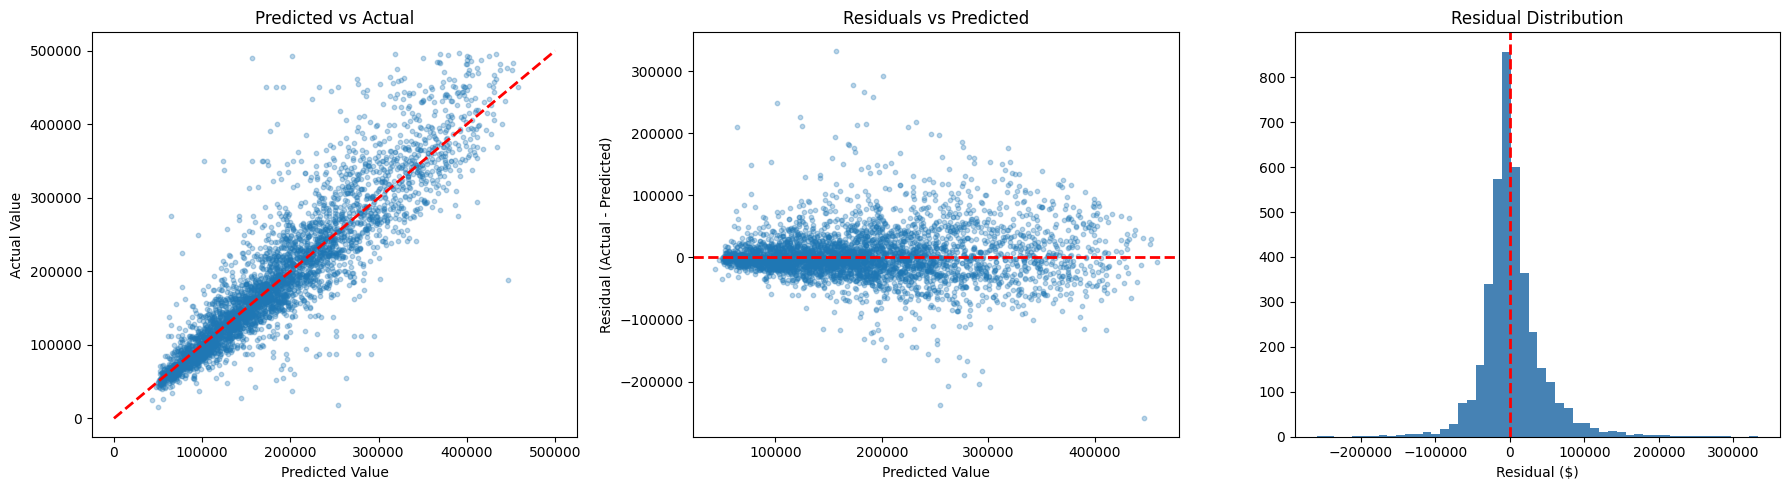

Mean residual: $3,442.37
Residual std: $41,467.46


In [20]:
# Cell 20: Residual analysis plots
residuals = y_test_dollars - y_pred_dollars

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_dollars, y_test_dollars, alpha=0.3, s=10)
axes[0].plot([0, 500000], [0, 500000], 'r--', lw=2)
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Actual Value')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(y_pred_dollars, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=50, color='steelblue')
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Residual ($)')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Residual std: ${residuals.std():,.2f}")

In [21]:
# Cell 21: SHAP explainability — understand which features drive predictions
!pip install shap -q

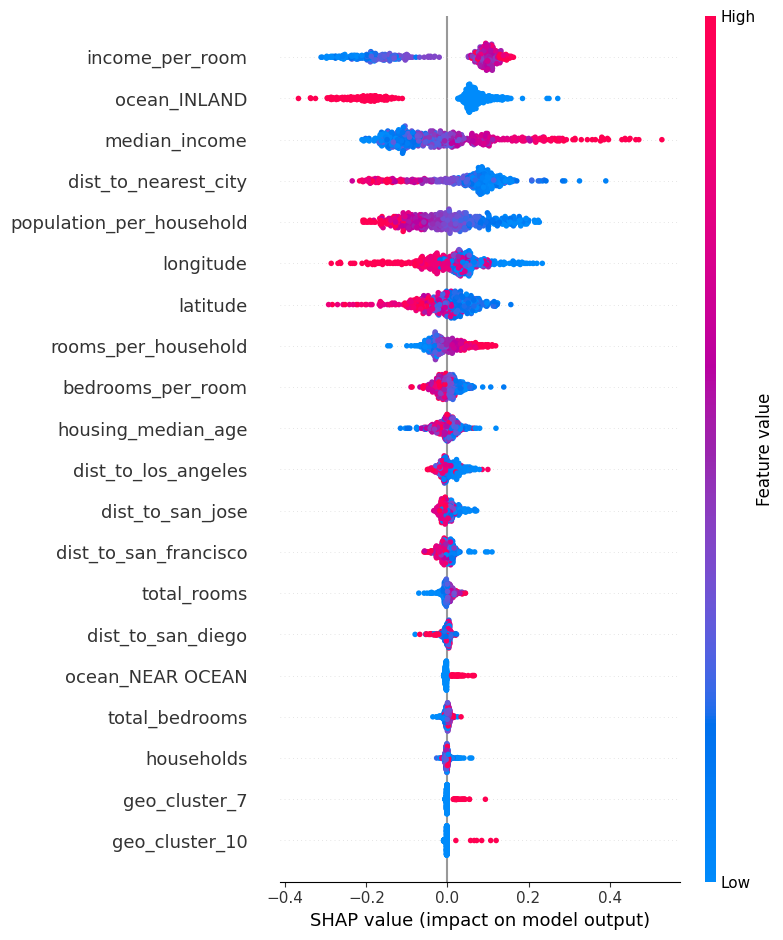

In [22]:
# Cell 22: Compute and visualize SHAP values
import shap

X_test_transformed = final_pipe.named_steps['preprocessor'].transform(X_test)

feature_names = (numeric_features +
                  list(final_pipe.named_steps['preprocessor'].named_transformers_['geo_cat'].get_feature_names_out(['geo_cluster'])) +
                  ocean_cols)

explainer = shap.TreeExplainer(final_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed[:500])  # sample for speed

shap.summary_plot(shap_values, X_test_transformed[:500], feature_names=feature_names, show=True)